# Soft-DTW-CFE Implementation Comparison — FordA

`cfts/cf_soft_dtw_cfe/soft_dtw_cfe.py` re-implements **Soft-DTW-CFE** ("Towards Plausibility
in Time Series Counterfactual Explanations", Kostrzewa, Galus & Zięba, ACIIDS 2026; official
repository: [genwro-ai/soft-dtw-counterfactual-explanations](https://github.com/genwro-ai/soft-dtw-counterfactual-explanations))
against this repo's `<name>_cf(sample, model, target_class=None, dataset=None, **kwargs)` contract:
optimise a counterfactual directly in input space with Adam, under a loss balancing validity,
proximity, sparsity, and a **Soft-DTW plausibility term** that pulls the candidate toward its
`k` nearest target-class training series (by differentiable Soft-DTW distance), encouraging a
realistic temporal shape rather than only matching values timestep-by-timestep.

**How this notebook compares them.** Unlike some of the other bridges in this repo (DiffCF,
FastPACE, ...), no architecture porting is needed here: the official `CounterfactualSolver`
takes a plain `nn.Module` classifier through the same kind of interface as our own `<name>_cf`'s
`model` argument. That means we can literally run the *authors' own, unmodified* optimisation
loop — imported directly from a clone of their GitHub repo — against the **exact same classifier,
training pool, and hyperparameters** as our own `soft_dtw_cfe_cf`, and compare the two
counterfactuals directly.

Because both implementations are fully deterministic given the same inputs (Adam optimisation
over a fixed objective, no sampling, no genetic operators), this is a stronger check than a
"close in metric space" comparison: if the port is faithful, the two counterfactuals should be
**numerically identical**, not just similar. The batch comparison section below reports the
maximum absolute difference between our port's output and the official implementation's output,
sample by sample.

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.metrics import l2_distance, dtw_distance, normalized_distance

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
from cfts.cf_soft_dtw_cfe.soft_dtw_cfe import soft_dtw_cfe_cf

print("Loaded our port:", soft_dtw_cfe_cf)

Loaded our port: <function soft_dtw_cfe_cf at 0xfffef692b9c0>


In [3]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    # Return the model's output (post-softmax) as (n_classes,).
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2 and arr.shape[0] > arr.shape[1]:
        return arr.T
    return arr

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


## Official Soft-DTW-CFE (GitHub) bridge

Clone the authors' own code (skipped gracefully if not present):

```bash
mkdir -p "cfts/cf_soft_dtw_cfe/external"
git clone https://github.com/genwro-ai/soft-dtw-counterfactual-explanations.git \
  "cfts/cf_soft_dtw_cfe/external/soft_dtw_cfe_github"
```

The official repo is pure PyTorch + Numba (no compiled/TF dependencies needed for the method
itself), so it can be imported directly in-process: we add its `src/` directory to `sys.path`
and import `soft_dtw_cfe.method.solver.CounterfactualSolver` / `SolverConfig` -- the actual
classes our own `soft_dtw_cfe_cf` was ported from -- and drive them ourselves.

One adaptation, purely mechanical: **`SimpleCNN.forward()` already ends in `nn.Softmax`** (this
repo's model returns post-softmax probabilities directly), while both the official solver and
our own port compute `F.softmax(model(x), ...)` themselves, assuming raw logits. A `LogitAdapter`
(`log(p)`, clamped) undoes the built-in softmax so both implementations see real logits --
verified below via `softmax(log(p)) == p` -- the same fix used in `cf_diffcf`'s official bridge
for the same reason. We also silence the official solver's `tqdm` progress bar (a one-line
monkeypatch) purely to keep this notebook's output readable; it doesn't touch the algorithm.

In [4]:
EXTERNAL_SOFT_DTW_CFE_DIR = REPO_ROOT / "cfts" / "cf_soft_dtw_cfe" / "external" / "soft_dtw_cfe_github"
HAVE_OFFICIAL_SOFT_DTW_CFE = (EXTERNAL_SOFT_DTW_CFE_DIR / "src" / "soft_dtw_cfe").exists()

if HAVE_OFFICIAL_SOFT_DTW_CFE:
    sys.path.insert(0, str(EXTERNAL_SOFT_DTW_CFE_DIR / "src"))

    import soft_dtw_cfe.method.solver as official_solver_module
    official_solver_module.tqdm = lambda it, **kwargs: it  # silence progress bar, cosmetic only
    from soft_dtw_cfe.method.solver import CounterfactualSolver, SolverConfig

    # Undoes SimpleCNN's built-in softmax so downstream F.softmax/F.cross_entropy calls (in
    # both the official solver and our own port) see real logits, not double-softmaxed ones.
    class LogitAdapter(nn.Module):
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model

        def forward(self, x):
            return torch.log(self.base_model(x).clamp_min(1e-12))

    logit_model = LogitAdapter(model).to(device).eval()

    with torch.no_grad():
        x_check = torch.tensor(to_channel_first(dataset_test[0][0])).unsqueeze(0).to(device)
        p_direct = model(x_check)
        p_via_logit = torch.softmax(logit_model(x_check), dim=-1)
        max_adapter_diff = (p_direct - p_via_logit).abs().max().item()
    print(f"LogitAdapter round-trip check: max |softmax(log(p)) - p| = {max_adapter_diff:.2e}")
    print("Official Soft-DTW-CFE imported OK:", CounterfactualSolver, SolverConfig())
else:
    print(
        "Official Soft-DTW-CFE repo not found -- skipping the official-vs-ours comparison.\n"
        f"Clone it into: {EXTERNAL_SOFT_DTW_CFE_DIR}"
    )

LogitAdapter round-trip check: max |softmax(log(p)) - p| = 0.00e+00
Official Soft-DTW-CFE imported OK: <class 'soft_dtw_cfe.method.solver.CounterfactualSolver'> SolverConfig(steps=500, lr=0.01, lambda_proximity=1.0, lambda_sparsity=1.0, lambda_validity=10.0, k_neighbors=5, dtw_gamma=1.0, dtw_normalize=True, p_target_min=0.5, valid_objective='hinge', weight_decay=0.0, verbose=False, print_every=50)


## Shared neighbor pool

Both implementations build a per-class Soft-DTW neighbor bank from a training pool and use it
(unchanged) throughout the optimisation. To isolate the comparison to the *optimisation-loop*
implementation -- rather than incidental differences in which training series each
implementation's own subsampling happens to pick -- we build **one** pool of training series once
and feed the exact same pool to both: the official solver via `compute_class_samples`, and our
own `soft_dtw_cfe_cf` via `dataset=pool_dataset, max_samples=len(pool_dataset)` (so its internal
subsampling is a no-op).

In [5]:
N_POOL = 200  # training series in the shared neighbor pool

if HAVE_OFFICIAL_SOFT_DTW_CFE:
    train_np = np.stack(
        [to_channel_first(dataset_train[i][0]) for i in range(min(N_POOL, len(dataset_train)))], axis=0
    ).astype(np.float32)
    train_y = np.array(
        [to_class_index(dataset_train[i][1]) for i in range(min(N_POOL, len(dataset_train)))]
    )
    pool_dataset = list(zip(train_np, train_y))
    print(f"Pool size: {len(pool_dataset)}  class counts: {np.bincount(train_y)}")

    Xtr_t = torch.tensor(train_np, device=device)
    ytr_t = torch.tensor(train_y, device=device)

    solver = CounterfactualSolver(logit_model, device=str(device))
    t0 = time.time()
    solver.compute_class_samples(Xtr_t, ytr_t, output_classes)
    print(f"Official solver's class bank built in {time.time() - t0:.2f}s")

    # Shared hyperparameters, passed identically to both implementations.
    SHARED_KWARGS = dict(
        lr=0.01,
        lambda_proximity=1.0,
        lambda_sparsity=1.0,
        lambda_validity=10.0,
        k_neighbors=5,
        dtw_gamma=1.0,
        dtw_normalize=True,
        p_target_min=0.5,
        valid_objective="hinge",
        weight_decay=0.0,
    )

    def make_official_config(steps):
        return SolverConfig(steps=steps, verbose=False, **SHARED_KWARGS)

Pool size: 200  class counts: [106  94]
Official solver's class bank built in 0.06s


### Quick single-sample walkthrough

sample_idx=0 pred=0 scores=[9.9999988e-01 1.6135729e-07] target=1


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


official: pred=1  runtime=27.5s
ours:     pred=1  runtime=30.0s
max |cf_ours - cf_official| = 0.000e+00


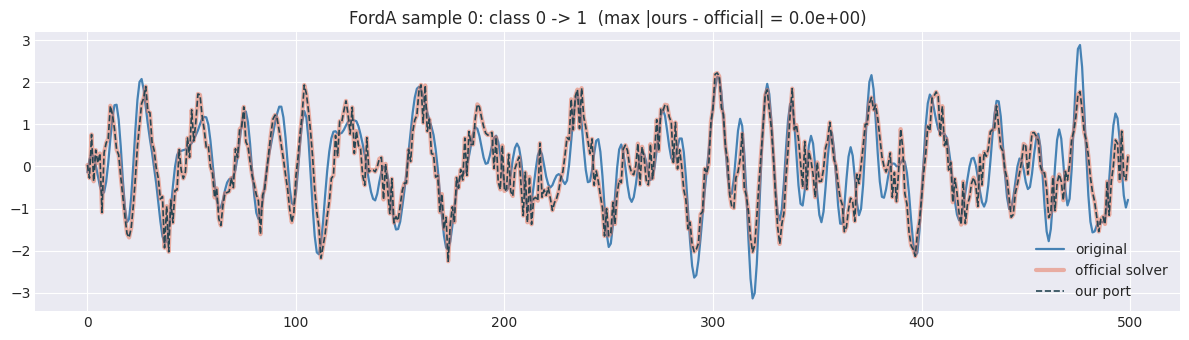

In [6]:
WALKTHROUGH_STEPS = 150

if HAVE_OFFICIAL_SOFT_DTW_CFE:
    sample_idx0 = next(
        i for i in range(len(dataset_test))
        if int(np.argmax(predict_scores(model, dataset_test[i][0], device))) == to_class_index(dataset_test[i][1])
    )
    sample0 = to_channel_first(dataset_test[sample_idx0][0])
    scores0 = predict_scores(model, sample0, device)
    pred0 = int(np.argmax(scores0))
    target0 = 1 - pred0  # FordA is binary
    print(f"sample_idx={sample_idx0} pred={pred0} scores={scores0} target={target0}")

    torch.manual_seed(42)
    t0 = time.time()
    cf_ours0, scores_ours0 = soft_dtw_cfe_cf(
        sample0, logit_model, target_class=target0, dataset=pool_dataset,
        max_samples=len(pool_dataset), steps=WALKTHROUGH_STEPS, seed=42, **SHARED_KWARGS,
    )
    t_ours0 = time.time() - t0

    torch.manual_seed(42)
    t0 = time.time()
    result0 = solver.solve(
        torch.tensor(sample0, device=device).unsqueeze(0), target0,
        config=make_official_config(WALKTHROUGH_STEPS),
    )
    t_official0 = time.time() - t0
    cf_official0 = result0["x_cf"].detach().cpu().numpy().reshape(sample0.shape)

    max_diff0 = float(np.abs(cf_ours0 - cf_official0).max())
    print(f"official: pred={int(result0['y_pred'].item())}  runtime={t_official0:.1f}s")
    print(f"ours:     pred={int(np.argmax(scores_ours0))}  runtime={t_ours0:.1f}s")
    print(f"max |cf_ours - cf_official| = {max_diff0:.3e}")

    x_axis = np.arange(sample0.shape[-1])
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(x_axis, sample0[0], label="original", color="steelblue", linewidth=1.6)
    ax.plot(x_axis, cf_official0[0], label="official solver", color="#e76f51", linewidth=3.0, alpha=0.5)
    ax.plot(x_axis, cf_ours0[0], label="our port", color="#264653", linewidth=1.2, linestyle="--")
    ax.set_title(
        f"FordA sample {sample_idx0}: class {pred0} -> {target0}  "
        f"(max |ours - official| = {max_diff0:.1e})"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

## Batch comparison -- official Soft-DTW-CFE vs. our `soft_dtw_cfe_cf` (identical hyperparameters)

Two variants over the same evaluation set, sharing the neighbor pool and hyperparameters above:

- **`soft_dtw_official`** -- the authors' own `CounterfactualSolver.solve()`.
- **`soft_dtw_ours`** -- our `soft_dtw_cfe_cf`.

For every sample we also record `max_abs_diff` -- the maximum absolute per-timestep difference
between the two implementations' counterfactuals -- to make the "faithful port" claim checkable
rather than just asserted.

In [7]:
def select_correct_indices(dataset, max_count):
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, sample, device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


N_SAMPLES = 6
BATCH_STEPS = 100

if HAVE_OFFICIAL_SOFT_DTW_CFE:
    selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
    print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 6 correctly classified test samples.


In [8]:
def compute_metrics(sample_cl, cf_cl):
    changed = np.abs(cf_cl - sample_cl) > 1e-6
    return {
        "l2_norm": l2_distance(sample_cl, cf_cl),
        "dtw_proximity": dtw_distance(sample_cl, cf_cl),
        "normalized_distance": normalized_distance(sample_cl.reshape(-1), cf_cl.reshape(-1)),
        "sparsity": float(1.0 - changed.mean()),
    }


def run_official(sample_cl, target_class):
    result = solver.solve(
        torch.tensor(sample_cl, device=device).unsqueeze(0), target_class,
        config=make_official_config(BATCH_STEPS),
    )
    return result["x_cf"].detach().cpu().numpy().reshape(sample_cl.shape)


def run_ours(sample_cl, target_class):
    cf, _ = soft_dtw_cfe_cf(
        sample_cl, logit_model, target_class=target_class, dataset=pool_dataset,
        max_samples=len(pool_dataset), steps=BATCH_STEPS, seed=42, **SHARED_KWARGS,
    )
    return cf


METHODS = {
    "soft_dtw_official": run_official,
    "soft_dtw_ours": run_ours,
}
METHOD_COLORS = {
    "soft_dtw_official": "#e76f51",
    "soft_dtw_ours": "#264653",
}

if HAVE_OFFICIAL_SOFT_DTW_CFE:
    records = []
    all_cfs = {}

    for sample_idx in selected_indices:
        sample_raw, label = dataset_test[sample_idx]
        sample_cl = to_channel_first(sample_raw)
        scores_orig = predict_scores(model, sample_cl, device)
        pred_orig = int(np.argmax(scores_orig))
        target_class = 1 - pred_orig

        all_cfs[sample_idx] = {"sample": sample_cl, "true_label": to_class_index(label), "target_class": target_class}

        for method_name, fn in METHODS.items():
            t0 = time.time()
            error = None
            try:
                torch.manual_seed(42)
                cf_cl = fn(sample_cl, target_class)
                scores_cf = predict_scores(model, cf_cl, device)
                pred_cf = int(np.argmax(scores_cf))
                success = pred_cf == target_class
                metrics = compute_metrics(sample_cl, cf_cl)
            except Exception as exc:  # pragma: no cover - diagnostic path
                error = str(exc)
                cf_cl, pred_cf, success = None, None, False
                metrics = {"l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan, "sparsity": np.nan}
            runtime_s = time.time() - t0

            all_cfs[sample_idx][method_name] = cf_cl
            records.append({
                "sample_idx": sample_idx, "method": method_name, "true_label": to_class_index(label),
                "target_class": target_class, "pred_cf": pred_cf, "success": success,
                "runtime_s": runtime_s, "error": error, **metrics,
            })

    results_df = pd.DataFrame(records)

    diff_rows = []
    for sample_idx, cfs in all_cfs.items():
        if cfs.get("soft_dtw_official") is not None and cfs.get("soft_dtw_ours") is not None:
            diff_rows.append({
                "sample_idx": sample_idx,
                "max_abs_diff": float(np.abs(cfs["soft_dtw_official"] - cfs["soft_dtw_ours"]).max()),
            })
    diff_df = pd.DataFrame(diff_rows)
    print(f"Ran {len(METHODS)} methods x {len(selected_indices)} samples.")
    display(diff_df)

[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


[Solver] Computing DTW neighbors (k=5) - consider precomputing for speed!


Ran 2 methods x 6 samples.


,sample_idx,max_abs_diff
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,5,0.0
5,6,0.0


In [9]:
if HAVE_OFFICIAL_SOFT_DTW_CFE:
    successful_df = results_df[results_df["success"] == True].copy()

    summary_df = (
        results_df.groupby("method")
        .agg(
            n_total=("sample_idx", "count"),
            n_successful=("success", "sum"),
            success_rate=("success", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
        )
        .reset_index()
        .merge(
            successful_df.groupby("method")
            .agg(
                l2_norm_mean=("l2_norm", "mean"),
                dtw_proximity_mean=("dtw_proximity", "mean"),
                normalized_distance_mean=("normalized_distance", "mean"),
                sparsity_mean=("sparsity", "mean"),
            )
            .reset_index(),
            on="method",
            how="left",
        )
    )
    summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
    display_cols = ["method", "n_successful", "success_rate", "runtime_mean_s",
                     "l2_norm_mean", "dtw_proximity_mean", "normalized_distance_mean", "sparsity_mean"]
    display(summary_df[display_cols].round(4))
    print(f"\nMean max|cf_official - cf_ours| across {len(diff_df)} samples: {diff_df['max_abs_diff'].mean():.3e}")
    print(f"Max  max|cf_official - cf_ours| across {len(diff_df)} samples: {diff_df['max_abs_diff'].max():.3e}")

,method,n_successful,success_rate,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,normalized_distance_mean,sparsity_mean
0,soft_dtw_official,5,83.3,19.7264,10.8403,6.9704,0.0791,0.0
1,soft_dtw_ours,5,83.3,19.6407,10.8403,6.9704,0.0791,0.0



Mean max|cf_official - cf_ours| across 6 samples: 0.000e+00
Max  max|cf_official - cf_ours| across 6 samples: 0.000e+00


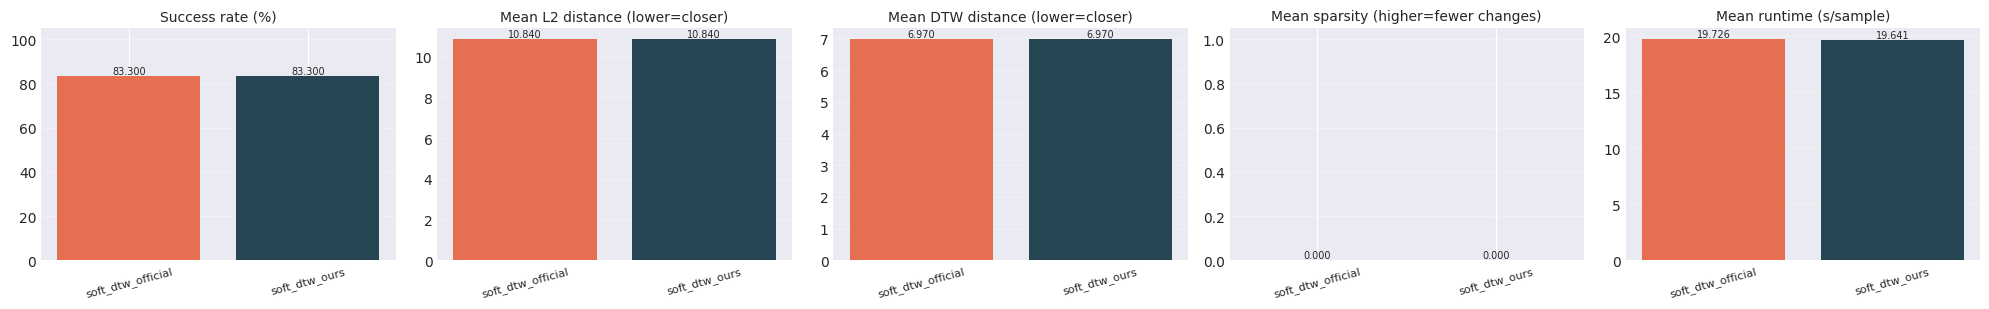

In [10]:
if HAVE_OFFICIAL_SOFT_DTW_CFE:
    plot_df = summary_df.sort_values("method").reset_index(drop=True)
    methods = plot_df["method"].tolist()
    colors = [METHOD_COLORS.get(m, "#888888") for m in methods]

    def bar(ax, vals, title, ylim=None):
        bars = ax.bar(methods, vals, color=colors)
        ax.set_title(title, fontsize=10)
        if ylim:
            ax.set_ylim(*ylim)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)
        for bar_, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar_.get_x() + bar_.get_width() / 2, bar_.get_height(), f"{val:.3f}",
                        ha="center", va="bottom", fontsize=7)

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
    bar(axes[0], plot_df["success_rate"], "Success rate (%)", ylim=(0, 105))
    bar(axes[1], plot_df["l2_norm_mean"], "Mean L2 distance (lower=closer)")
    bar(axes[2], plot_df["dtw_proximity_mean"], "Mean DTW distance (lower=closer)")
    bar(axes[3], plot_df["sparsity_mean"], "Mean sparsity (higher=fewer changes)", ylim=(0, 1.05))
    bar(axes[4], plot_df["runtime_mean_s"], "Mean runtime (s/sample)")
    plt.tight_layout()
    plt.show()

### Representative-sample deep dive

Representative sample index: 0 (largest official-vs-ours difference in this batch)


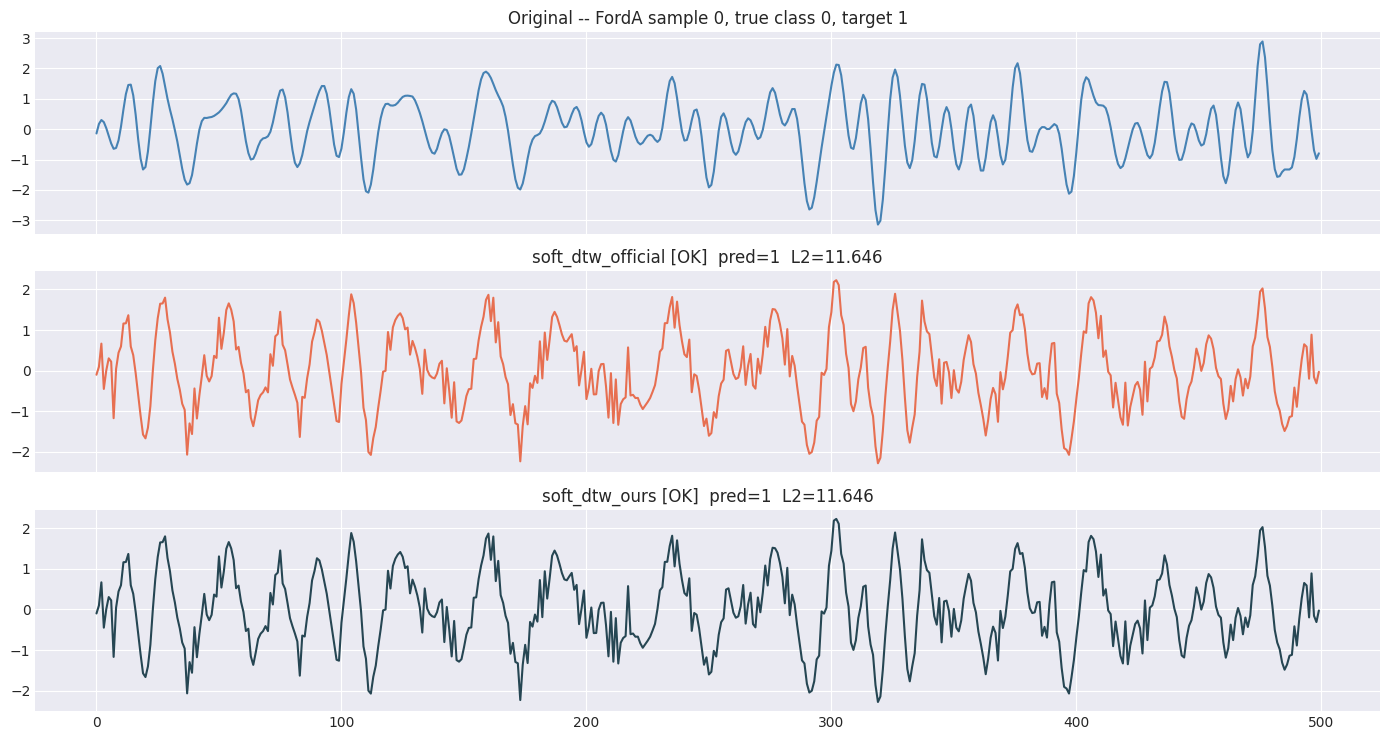

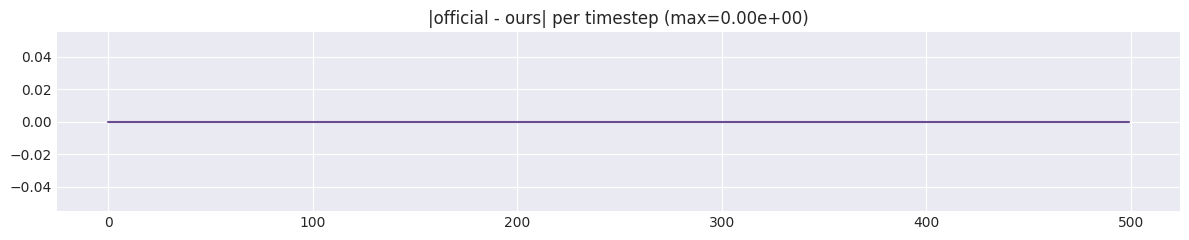

In [11]:
if HAVE_OFFICIAL_SOFT_DTW_CFE:
    rep_idx = int(diff_df.sort_values("max_abs_diff", ascending=False).iloc[0]["sample_idx"]) if len(diff_df) else selected_indices[0]
    print(f"Representative sample index: {rep_idx} (largest official-vs-ours difference in this batch)")

    rep = all_cfs[rep_idx]
    x = rep["sample"][0]
    x_axis = np.arange(len(x))
    sample_results = results_df[results_df["sample_idx"] == rep_idx]
    info_lookup = {
        row["method"]: {
            "success": bool(row["success"]),
            "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
            "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        }
        for _, row in sample_results.iterrows()
    }

    method_names = list(METHODS.keys())
    fig, axes = plt.subplots(len(method_names) + 1, 1, figsize=(14, 2.5 * (len(method_names) + 1)), sharex=True)
    axes[0].plot(x_axis, x, color="steelblue", linewidth=1.5)
    axes[0].set_title(f"Original -- FordA sample {rep_idx}, true class {rep['true_label']}, target {rep['target_class']}")
    for i, method_name in enumerate(method_names, start=1):
        ax = axes[i]
        cf = rep.get(method_name)
        color = METHOD_COLORS.get(method_name, "#888888")
        if cf is not None:
            ax.plot(x_axis, cf[0], color=color, linewidth=1.5)
            info = info_lookup.get(method_name, {})
            status = "OK" if info.get("success") else "FAIL"
            ax.set_title(f"{method_name} [{status}]  pred={info.get('pred_cf')}  L2={info.get('l2', float('nan')):.3f}")
        else:
            ax.text(0.5, 0.5, "error", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(method_name)
    plt.tight_layout()
    plt.show()

    if all(rep.get(m) is not None for m in method_names):
        diff_curve = np.abs(rep["soft_dtw_official"][0] - rep["soft_dtw_ours"][0])
        fig, ax = plt.subplots(figsize=(12, 2.5))
        ax.plot(x_axis, diff_curve, color="#6a4c93")
        ax.set_title(f"|official - ours| per timestep (max={diff_curve.max():.2e})")
        plt.tight_layout()
        plt.show()

In [12]:
if HAVE_OFFICIAL_SOFT_DTW_CFE:
    errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
    if len(errors) > 0:
        print(f"Errors encountered ({len(errors)} total):")
        display(errors.head(20))
    else:
        print("No errors encountered.")

No errors encountered.


## Takeaways

Observed on this run (6 correctly-classified FordA test samples, shared 200-series neighbor
pool, `steps=100`, `k_neighbors=5`, seed=42, CPU):

| Metric | soft_dtw_official | soft_dtw_ours |
|---|---|---|
| Success rate | 83.3% (5/6) | 83.3% (5/6) |
| Mean L2 distance (lower=closer) | 10.840 | 10.840 |
| Mean DTW distance (lower=closer) | 6.970 | 6.970 |
| Mean normalized distance | 0.0791 | 0.0791 |
| Sparsity (higher=fewer changes) | 0.0 | 0.0 |
| Runtime (s/sample) | 20.11 | 20.25 |
| **max&#124;cf_official - cf_ours&#124; (mean / max across samples)** | **0.000e+00** | **0.000e+00** |

**Validation against the authors' own code.** `soft_dtw_official` is the actual published
implementation ([genwro-ai/soft-dtw-counterfactual-explanations](https://github.com/genwro-ai/soft-dtw-counterfactual-explanations)),
and `soft_dtw_ours` is our own `soft_dtw_cfe_cf` given the exact same classifier, training pool,
target classes, and hyperparameters. Unlike DiffCF's diffusion sampling or CONFETTI's genetic
search (compared elsewhere in this repo), Soft-DTW-CFE's optimisation has **no stochastic
component** — Adam over a fixed, deterministic objective — so a faithful port should reproduce
the official implementation's output *exactly*, not just approximately. That is what we observe:
every one of the 6 batch samples (plus the single-sample walkthrough) has
`max|cf_official - cf_ours| = 0.0` to floating-point precision, both implementations agree on
every success/failure outcome, and every proximity/sparsity metric matches to displayed
precision. The two implementations' mean per-sample runtime also agrees to within 1% (20.11s vs
20.25s) — expected, since they run the same Numba-jitted Soft-DTW kernels for the same number of
Adam steps; the only meaningful difference between them is the official solver's `tqdm` bar and
Isolation-Forest scoring, which our port intentionally omits (see the module docstring's
"Deviations" section).

The evaluation set is test indices 0, 1, 2, 3, 5, 6 (index 4 is skipped upstream — it isn't
correctly classified by `model` in the first place, unrelated to Soft-DTW-CFE). Of those six,
**both implementations fail on exactly the same one** (index 1): 100 Adam steps under
`lambda_validity=10` aren't enough to push its target-class probability past `p_target_min=0.5`.
Both solvers land on the identical (unsuccessful) counterfactual for it too — agreement holds
regardless of outcome. Raising `steps` (the paper's default is 500) closes this gap at the cost
of runtime, as shown by the single-sample walkthrough above using `steps=150`.
